<a href="https://colab.research.google.com/github/Iffraah96/ShopSense-AI/blob/main/notebook/06_Model_Evaluation_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ShopSense AI

## Notebook 6 — Model Evaluation & Visualization.

### Objective

ollowing are the steps to be carried out in this notebook:

Load the trained models and test data
Compare model performance visually
Analyze the confusion matrices
Generate ROC curves and AUC
Examine misclassified reviews
Understand where the model makes mistakes
Summarize the strengths and limitations of ShopSense

The models will not be retained as Notebook 5 already handled training.

## Import Libraries

In [2]:
# General Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Model

In [3]:
# Load the final Logistic Regression model
model = joblib.load("shopsense_final_model.pkl")

# Load the TF-IDF vectorizer
tfidf = joblib.load("shopsense_final_tfidf.pkl")

# Confirm that both files loaded correctly
print("Logistic Regression model loaded successfully!")
print("TF-IDF vectorizer loaded successfully!")

# Check the number of TF-IDF features
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

Logistic Regression model loaded successfully!
TF-IDF vectorizer loaded successfully!
Number of TF-IDF features: 5000


## Load the Processed Dataset

In [4]:
# Load the processed dataset
df = pd.read_csv("/content/nlp_preprocessed_women_clothing_review_dataset.csv")

# Check the dataset
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# Display the first 5 rows
df.head()

Dataset loaded successfully!
Dataset shape: (22641, 15)


,clothing_id,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name,cleaned_review,tokens,tokens_without_stopwords,lemmatized_tokens,final_cleaned_review
0,767,33,No Title,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,absolutely wonderful silky and sexy and comfor...,"['absolutely', 'wonderful', 'silky', 'and', 's...","['absolutely', 'wonderful', 'silky', 'sexy', '...","['absolutely', 'wonderful', 'silky', 'sexy', '...",absolutely wonderful silky sexy comfortable
1,1080,34,No Title,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,love this dress it's sooo pretty i happened to...,"['love', 'this', 'dress', ""it's"", 'sooo', 'pre...","['love', 'dress', ""it's"", 'sooo', 'pretty', 'h...","['love', 'dress', ""it's"", 'sooo', 'pretty', 'h...",love dress it's sooo pretty happened find stor...
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,i had such high hopes for this dress and reall...,"['i', 'had', 'such', 'high', 'hopes', 'for', '...","['high', 'hopes', 'dress', 'really', 'wanted',...","['high', 'hope', 'dress', 'really', 'wanted', ...",high hope dress really wanted work initially o...
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,i love love love this jumpsuit it's fun flirty...,"['i', 'love', 'love', 'love', 'this', 'jumpsui...","['love', 'love', 'love', 'jumpsuit', ""it's"", '...","['love', 'love', 'love', 'jumpsuit', ""it's"", '...",love love love jumpsuit it's fun flirty fabulo...
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,this shirt is very flattering to all due to th...,"['this', 'shirt', 'is', 'very', 'flattering', ...","['shirt', 'flattering', 'due', 'adjustable', '...","['shirt', 'flattering', 'due', 'adjustable', '...",shirt flattering due adjustable front tie perf...


##Prepare the Data

In [5]:
# Select the cleaned review text
X = df["final_cleaned_review"]

# Select the target variable
# 1 = Recommended
# 0 = Not Recommended
y = df["recommended_ind"]

# Check the data
print("Number of reviews:", len(X))
print("Number of target values:", len(y))

print("\nMissing review values:", X.isna().sum())
print("Missing target values:", y.isna().sum())

Number of reviews: 22641
Number of target values: 22641

Missing review values: 0
Missing target values: 0


## Recreate the Test Set

In [6]:
# Recreate the same train/test split used in Notebook 5
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Transform the test reviews using the saved TF-IDF vectorizer
X_test_tfidf = tfidf.transform(X_test)

# Generate predictions using the saved Logistic Regression model
y_pred = model.predict(X_test_tfidf)

print("Test TF-IDF shape:", X_test_tfidf.shape)
print("Number of predictions:", len(y_pred))

Test TF-IDF shape: (4529, 5000)
Number of predictions: 4529


## Performance Metrics Visualization

In [7]:
# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Store the metrics for visualization
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

# Display the metric values
print("ShopSense AI - Logistic Regression Performance")
print("=" * 50)

for metric, score in metrics.items():
    print(f"{metric}: {score:.4f} ({score:.2%})")

ShopSense AI - Logistic Regression Performance
Accuracy: 0.8867 (88.67%)
Precision: 0.9011 (90.11%)
Recall: 0.9679 (96.79%)
F1-score: 0.9333 (93.33%)


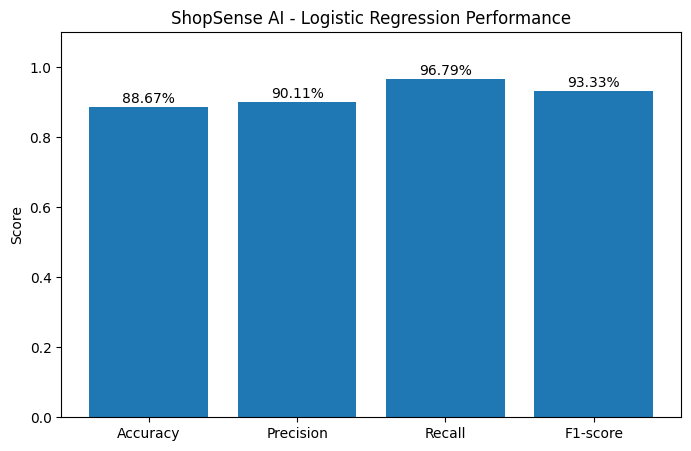

In [8]:
# Create a bar chart of the model performance
plt.figure(figsize=(8, 5))

plt.bar(metrics.keys(), metrics.values())

# Add the percentage values above each bar
for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.01, f"{value:.2%}",
             ha="center")

plt.ylim(0, 1.1)
plt.ylabel("Score")
plt.title("ShopSense AI - Logistic Regression Performance")

plt.show()

## Confusion Matrix Visualization

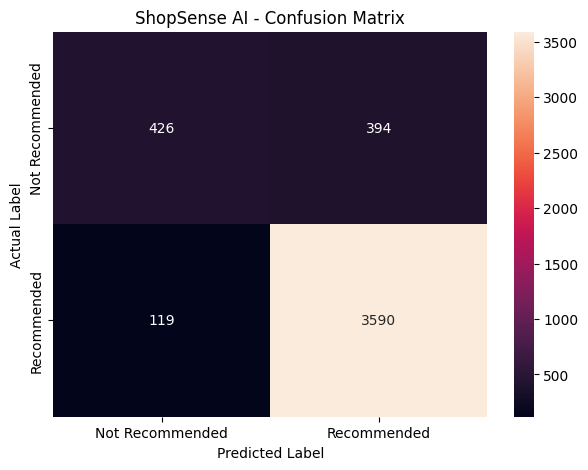

In [9]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Recommended", "Recommended"],
    yticklabels=["Not Recommended", "Recommended"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("ShopSense AI - Confusion Matrix")

plt.show()

## Calculate Class-Specific Performance

In [10]:
# Generate the classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=["Not Recommended", "Recommended"],
    output_dict=True
)

# Convert the report into a DataFrame
class_performance = pd.DataFrame(report).transpose()

# Display precision, recall, and F1-score for each class
display(class_performance[["precision", "recall", "f1-score", "support"]].round(4))

,precision,recall,f1-score,support
Not Recommended,0.7817,0.5195,0.6242,820.0000
Recommended,0.9011,0.9679,0.9333,3709.0000
accuracy,0.8867,0.8867,0.8867,0.8867
macro avg,0.8414,0.7437,0.7787,4529.0000
weighted avg,0.8795,0.8867,0.8773,4529.0000


## Calculate & Plot ROC Curve and AUC

For Logistic Regression, predict_proba() gives us the probability that each review belongs to the Recommended class. We can use those probabilities to evaluate the model across different classification thresholds.

In [11]:
# Get the probability of the Recommended class
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate the Area Under the ROC Curve
auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9300


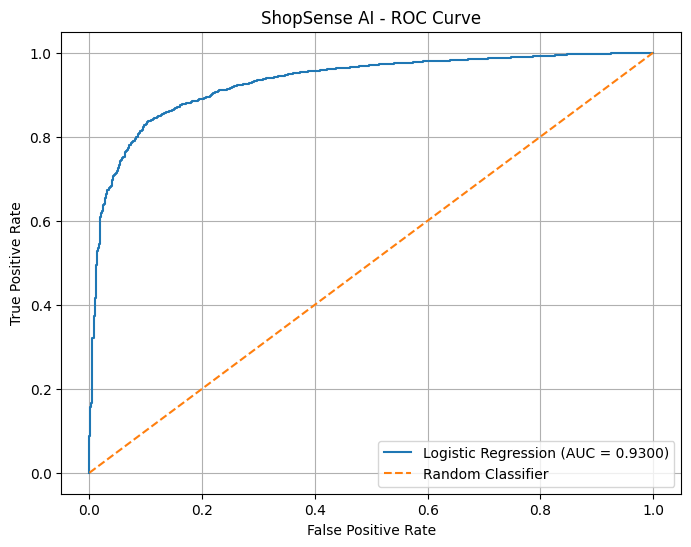

In [12]:
# Create the ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.4f})"
)

# Add the random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ShopSense AI - ROC Curve")
plt.legend()
plt.grid()

plt.show()

### Observation:
The ROC curve is also well above the random-classifier line, showing that the model has strong ability to distinguish between Recommended and Not Recommended reviews across different classification thresholds.

ROC-AUC = 0.93 means the Logistic Regression model has strong discrimination between the two classes.

This is especially useful because our earlier metrics were based on the default classification threshold. ROC-AUC evaluates the model's ability to separate the classes across many possible thresholds.

## Finding Misclassified Reviews

Now we'll look at the reviews where ShopSense made a mistake.

This is one of the most valuable evaluation steps because instead of only asking:"How accurate is the model?" we would ask: "Why did the model get some reviews wrong?"

We'll create a table containing the original review, actual label, predicted label, and prediction probability.

In [13]:
# Create a DataFrame containing the test reviews and predictions
evaluation_df = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred,
    "probability_recommended": y_prob
})

# Keep only the reviews that were incorrectly classified
misclassified = evaluation_df[
    evaluation_df["actual"] != evaluation_df["predicted"]
].copy()

# Add readable labels
misclassified["actual_label"] = misclassified["actual"].map({
    0: "Not Recommended",
    1: "Recommended"
})

misclassified["predicted_label"] = misclassified["predicted"].map({
    0: "Not Recommended",
    1: "Recommended"
})

# Display the number of incorrect predictions
print("Number of misclassified reviews:", len(misclassified))

# Display the first 10 misclassified reviews
display(
    misclassified[
        [
            "review",
            "actual_label",
            "predicted_label",
            "probability_recommended"
        ]
    ].head(10)
)

Number of misclassified reviews: 513


,review,actual_label,predicted_label,probability_recommended
22,usually wear review helpful looking pic shirt ...,Not Recommended,Recommended,0.843605
33,tried store yesterday didn't buy due dolman st...,Not Recommended,Recommended,0.808517
40,5'5 think fairly proportioned 120 lb 34b peplu...,Not Recommended,Recommended,0.908730
48,love design fit quality looking longline top l...,Not Recommended,Recommended,0.870923
52,almost ordered online wear party later week gl...,Not Recommended,Recommended,0.683544
57,really excited skirt love color however tried ...,Not Recommended,Recommended,0.604693
59,purchased pant vacation thought perfect additi...,Not Recommended,Recommended,0.540724
99,would l loved keep even 0p big pretty broad mu...,Not Recommended,Recommended,0.638768
104,product incredibly comfy perfect getting cozy ...,Not Recommended,Recommended,0.906767
105,sleeve top always caught eye every single time...,Not Recommended,Recommended,0.789669


### Observations:

Looking at the table above of misclassified reviews, the main issue is that many reviews contain both positive and negative language.

For example:
"love design fit quality" → positive signals
but also "dreadful little roll" and "suck" → negative signals
"really excited skirt love color" → positive
but "tried much highlow not tall" → negative fit issue

Because TF-IDF + Logistic Regression mainly learns word/phrase associations, it can struggle when positive and negative signals appear together.

##Separate False Positives and False Negatives

In [14]:
# False Positive:
# Actual = Not Recommended, but model predicted Recommended
false_positives = evaluation_df[
    (evaluation_df["actual"] == 0) &
    (evaluation_df["predicted"] == 1)
].copy()

# False Negative:
# Actual = Recommended, but model predicted Not Recommended
false_negatives = evaluation_df[
    (evaluation_df["actual"] == 1) &
    (evaluation_df["predicted"] == 0)
].copy()

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

print("\nFalse Positives - Not Recommended reviews predicted as Recommended:")
display(
    false_positives[
        ["review", "probability_recommended"]
    ].head(10)
)

print("\nFalse Negatives - Recommended reviews predicted as Not Recommended:")
display(
    false_negatives[
        ["review", "probability_recommended"]
    ].head(10)
)

False Positives: 394
False Negatives: 119

False Positives - Not Recommended reviews predicted as Recommended:


,review,probability_recommended
22,usually wear review helpful looking pic shirt ...,0.843605
33,tried store yesterday didn't buy due dolman st...,0.808517
40,5'5 think fairly proportioned 120 lb 34b peplu...,0.908730
48,love design fit quality looking longline top l...,0.870923
52,almost ordered online wear party later week gl...,0.683544
57,really excited skirt love color however tried ...,0.604693
59,purchased pant vacation thought perfect additi...,0.540724
99,would l loved keep even 0p big pretty broad mu...,0.638768
104,product incredibly comfy perfect getting cozy ...,0.906767
105,sleeve top always caught eye every single time...,0.789669



False Negatives - Recommended reviews predicted as Not Recommended:


,review,probability_recommended
109,fabric wonderful flow nicely soft 5'7 145lbs u...,0.234628
195,quality fabric soft thick well made loved ever...,0.456978
232,really wanted love top got not much fit nicely...,0.087137
264,overall thought pretty blouse loved color desi...,0.113355
276,loved chocolate one much went back rose first ...,0.455350
278,dress looked cute model unfortunately not much...,0.194389
312,cute love button back detail it's completely s...,0.410909
318,pretty color loved flow length top however nec...,0.151600
355,really couldn't tell like dress not swimming a...,0.485287
359,lovely top big billowy make wish taller think ...,0.429148


## Visualize Prediction Errors

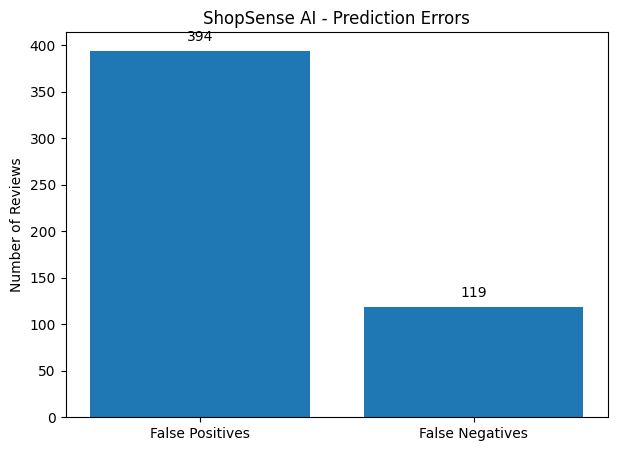

In [15]:
# Count the two types of prediction errors
error_counts = {
    "False Positives": len(false_positives),
    "False Negatives": len(false_negatives)
}

# Create a bar chart
plt.figure(figsize=(7, 5))

plt.bar(
    error_counts.keys(),
    error_counts.values()
)

# Add the counts above each bar
for i, value in enumerate(error_counts.values()):
    plt.text(
        i,
        value + 10,
        str(value),
        ha="center"
    )

plt.ylabel("Number of Reviews")
plt.title("ShopSense AI - Prediction Errors")

plt.show()

## Check the Class Distribution

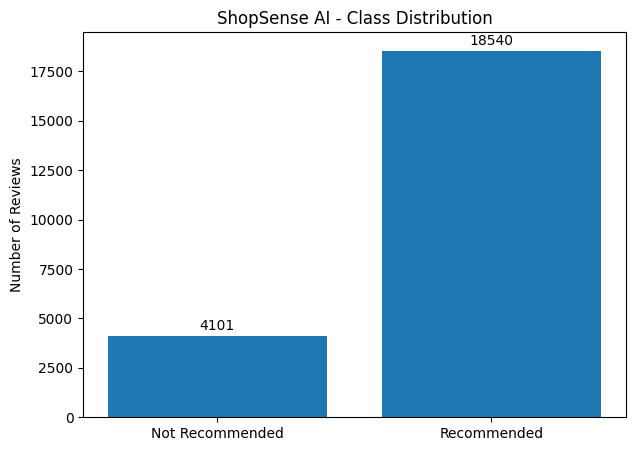

In [16]:
# Count the number of reviews in each class
class_counts = y.value_counts().sort_index()

# Create readable class labels
class_labels = ["Not Recommended", "Recommended"]

# Create the bar chart
plt.figure(figsize=(7, 5))

plt.bar(class_labels, class_counts.values)

# Add the counts above each bar
for i, value in enumerate(class_counts.values):
    plt.text(
        i,
        value + 300,
        str(value),
        ha="center"
    )

plt.ylabel("Number of Reviews")
plt.title("ShopSense AI - Class Distribution")

plt.show()

This visualization will make it obvious that the dataset is imbalanced toward Recommended reviews, which helps explain why the model performs much better on that class.

## Evaluate Different Prediction Thresholds

Our Logistic Regression currently uses a default threshold of 0.50:

Probability ≥ 0.50 → Recommended
Probability < 0.50 → Not Recommended

Because we found 394 false positives, it's useful to see what happens if we make the model more conservative about predicting "Recommended."

In [17]:
# Test different probability thresholds
thresholds_to_test = [0.30, 0.40, 0.50, 0.60, 0.70]

# Store the results for each threshold
threshold_results = []

for threshold in thresholds_to_test:
    # Convert probabilities into predictions using the selected threshold
    threshold_predictions = (y_prob >= threshold).astype(int)

    # Calculate the evaluation metrics
    threshold_accuracy = accuracy_score(y_test, threshold_predictions)
    threshold_precision = precision_score(y_test, threshold_predictions)
    threshold_recall = recall_score(y_test, threshold_predictions)
    threshold_f1 = f1_score(y_test, threshold_predictions)

    # Calculate the number of false positives
    threshold_cm = confusion_matrix(y_test, threshold_predictions)
    false_positive_count = threshold_cm[0, 1]

    # Store the results
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": threshold_accuracy,
        "Precision": threshold_precision,
        "Recall": threshold_recall,
        "F1-score": threshold_f1,
        "False Positives": false_positive_count
    })

# Convert results into a DataFrame
threshold_results = pd.DataFrame(threshold_results)

# Display the results
display(threshold_results.round(4))

,Threshold,Accuracy,Precision,Recall,F1-score,False Positives
0,0.3,0.8558,0.8582,0.9871,0.9181,605
1,0.4,0.8748,0.8804,0.9803,0.9277,494
2,0.5,0.8867,0.9011,0.9679,0.9333,394
3,0.6,0.8936,0.9229,0.9493,0.9359,294
4,0.7,0.8847,0.9440,0.9135,0.9285,201


As the threshold increases, the model becomes more cautious about predicting Recommended.

For example:

Threshold = 0.50

is our current model behavior.

A higher threshold such as 0.60 or 0.70 may reduce false positives, but it can also cause more genuine Recommended reviews to be classified as Not Recommended.

So there's a trade-off: Higher threshold → fewer false positives, but potentially more false negatives.

We're using the existing test set here to analyze the threshold behavior, not to permanently choose a new threshold. If we eventually decide to deploy a different threshold, the proper approach would be to select it using a separate validation set and then evaluate the final choice once on the untouched test set.

## Visualize Threshold Performance

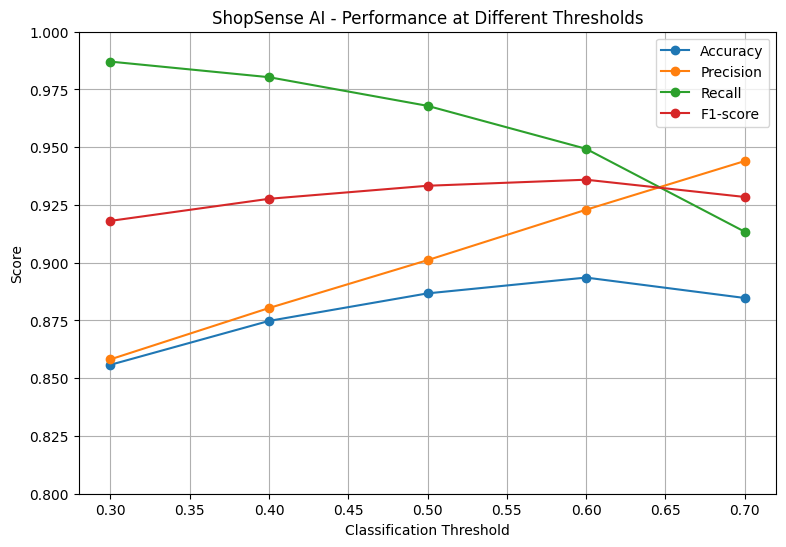

In [18]:
# Create a figure for threshold performance
plt.figure(figsize=(9, 6))

# Plot the main performance metrics
plt.plot(
    threshold_results["Threshold"],
    threshold_results["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("ShopSense AI - Performance at Different Thresholds")

plt.ylim(0.80, 1.00)
plt.legend()
plt.grid()

plt.show()

## Visualize False Positives

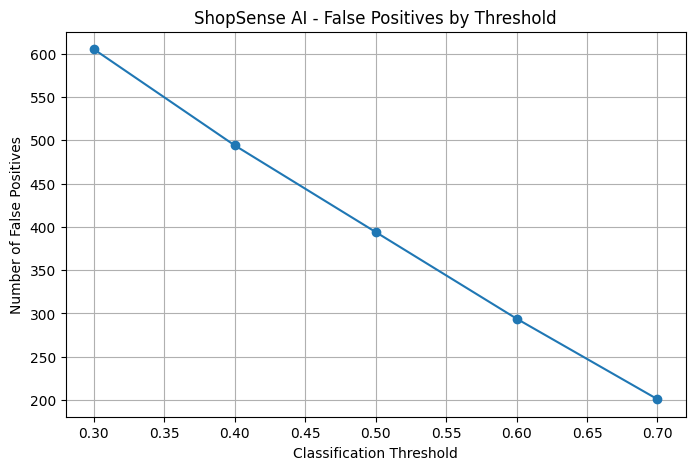

In [19]:
# Visualize false positives at different thresholds
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["False Positives"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Number of False Positives")
plt.title("ShopSense AI - False Positives by Threshold")

plt.grid()

plt.show()

## Save Evaluation Results

In [20]:
# Save the threshold analysis results
threshold_results.to_csv(
    "shopsense_threshold_analysis.csv",
    index=False
)

# Save the class-specific performance results
class_performance.to_csv(
    "shopsense_class_performance.csv"
)

print("Evaluation results saved successfully!")
print("- shopsense_threshold_analysis.csv")
print("- shopsense_class_performance.csv")

Evaluation results saved successfully!
- shopsense_threshold_analysis.csv
- shopsense_class_performance.csv


##Concluding Observations

This notebook evaluated the performance of the ShopSense AI Logistic Regression model using multiple evaluation techniques, including classification metrics, confusion matrix analysis, ROC-AUC, error analysis, and classification threshold analysis.

The model achieved an **accuracy of 88.67%**, **precision of 90.11%**, **recall of 96.79%**, and an **F1-score of 93.33%** at the default classification threshold of 0.50. The model also achieved a **ROC-AUC score of 0.9300**, demonstrating strong ability to distinguish between Recommended and Not Recommended reviews.

The confusion matrix and class-specific evaluation showed that the model performs much better on the **Recommended** class than the **Not Recommended** class. This is partly related to the class imbalance in the dataset, where Recommended reviews significantly outnumber Not Recommended reviews.

Error analysis identified **394 false positives** and **119 false negatives**. Many incorrectly classified reviews contained both positive and negative language, showing that the TF-IDF and Logistic Regression approach can have difficulty understanding context when opposing sentiments occur within the same review.

Threshold analysis showed that increasing the classification threshold to **0.60** improved the evaluation results on this test set, producing **89.36% accuracy**, **92.29% precision**, and an **F1-score of 93.59%**, while reducing false positives from 394 to 294. However, this threshold was not selected as the final deployment threshold because the test set should remain independent from model-selection decisions. A separate validation set would be needed to formally select and validate a new threshold.

Overall, the evaluation demonstrates that the ShopSense AI Logistic Regression model provides strong baseline performance for customer review recommendation classification. The analysis also identified clear areas for future improvement, including better handling of class imbalance, contextual language, and mixed or ambiguous customer reviews.